
1.1 Write Down the Model

CR3BP equations in rotating frame 
Jacobi constant CC 
Zero‑velocity curves (ZVCs) 
Deliverable

Clean derivation section (no code yet) 
Sketch of Hill’s regions vs CC 


In [1]:
# constants

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy

G = 1.0             # Gravitational constant (normalized)
M1 = 5.972e24       # Mass of Earth (primary)
M2 = 7.348e22       # Mass of Moon (secondary)
M3 = 1e-20          # Mass of tertiary (small asteroid)
omega = 1.0         # Angular velocity magnitude (normalized)
Omega = np.array([0, 0, 1]) * omega  # Angular velocity of the rotating frame
mu = M2 / (M1 + M2)
pos_earth = -mu * np.array([1, 0, 0])  # Earth at (mu, 0, 0)
pos_moon = (1 - mu) * np.array([1, 0, 0])
L1_x = 1 - (mu / 3)**(1/3)
L2_x = 1 + (mu / 3)**(1/3)
hill_radius = (mu / 3)**(1/3)



In [2]:
# common methods

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy

def calc_com(masses, pos):
    M = np.sum(masses)
    com = np.sum(pos * masses[:, None], axis=0) / M
    return com

def effective_potential(G, mu, pos_earth, pos_moon, pos_particle):
    r1 = np.linalg.norm(pos_particle - pos_earth)  # Distance to Earth
    r2 = np.linalg.norm(pos_particle - pos_moon)   # Distance to Moon
    potential = G * (1 - mu) / r1 + G * mu / r2 + 0.5 * np.linalg.norm(pos_particle[0:2])**2
    return potential

def calc_Jacobi_constant(state, mu):
    U = effective_potential(G, mu, pos_earth, pos_moon, state[:3])
    v_squared = np.linalg.norm(state[3:])**2
    jacobi = 2*U - v_squared
    return jacobi

def equations_of_motion(t, state, mu, masses):
    x, y, z, vx, vy, vz = state
    xdot  = vx
    ydot  = vy
    zdot  = vz

    r1 = np.sqrt((x+mu)**2 + y**2 + z**2)
    r2 = np.sqrt((x-1+mu)**2 + y**2 + z**2)

    vxdot = 2*vy + x - (1-mu)*(x+mu)/r1**3 - mu*(x-1+mu)/r2**3
    vydot = -2*vx + y - (1-mu)*y/r1**3 - mu*y/r2**3
    vzdot = -(1-mu)*z/r1**3 - mu*z/r2**3
    return [xdot, ydot, zdot, vxdot, vydot, vzdot]

def integrate_orbits(mu, masses, initial_state, t_span, dt):
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    
    sol = solve_ivp(
        fun=equations_of_motion,
        t_span=t_span,
        y0=initial_state,
        args=(mu, masses),
        t_eval=t_eval,
        method='DOP853',
        rtol=1e-10,
        atol=1e-12
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2], sol.y[3], sol.y[4], sol.y[5]

def trajectory_analysis(mu, masses, initial_state, t_span, dt):
    t, x, y, z, vx, vy, vz = integrate_orbits(mu, masses, initial_state, t_span, dt)
    jacobi_constants = np.array([calc_Jacobi_constant(state, mu) for state in zip(x, y, z, vx, vy, vz)])
    return t, x, y, z, vx, vy, vz, jacobi_constants

def find_zero_velocity_curve(mu, jacobi_constant, x_range):
    y_values = []
    for x in x_range:
        pos_particle = np.array([x, 0, 0])
        U = effective_potential(G, mu, pos_earth, pos_moon, pos_particle)
        if 2*U - jacobi_constant >= 0:
            y_values.append(np.sqrt(2*U - jacobi_constant))
        else:
            y_values.append(np.nan)  # No real solution for y
    return np.array(y_values)
 
# Inside the Moon's Hill sphere: r2<rH≈(μ3)1/3r2 <rH ≈(3μ )1/3
# Negative Kepler energy w.r.t. the Moon: E2=12∣vrel∣2−μr2<0E2 =21 ∣vrel ∣2−r2 μ <0
def is_captured(state, mu, hill_radius):
    """Check if particle is temporarily captured by the Moon."""
    x, y, z, vx, vy, vz = state
    # Moon position in rotating frame
    x_moon = 1 - mu
    
    # Distance to Moon
    r2 = np.sqrt((x - x_moon)**2 + y**2 + z**2)
    
    # Kepler energy relative to the Moon
    v_rel_sq = vx**2 + vy**2 + vz**2
    E2 = 0.5 * v_rel_sq - mu / r2
    
    return (r2 < hill_radius) and (E2 < 0)


# plot hills region vs jaobi constant for captured trajectories
'''plt.figure(figsize=(10, 6))
x_range = np.linspace(-0.5, 1.5, 1000)
for initial_state, jacobi in captured_traj:
    y_zero_velocity = find_zero_velocity_curve(mu, jacobi, x_range)
    plt.plot(x_range, y_zero_velocity, label=f'Jacobi={jacobi:.4f}')
plt.title('Zero-Velocity Curves for Captured Trajectories')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 0.5)
plt.grid()
plt.legend()
plt.show()
'''

"plt.figure(figsize=(10, 6))\nx_range = np.linspace(-0.5, 1.5, 1000)\nfor initial_state, jacobi in captured_traj:\n    y_zero_velocity = find_zero_velocity_curve(mu, jacobi, x_range)\n    plt.plot(x_range, y_zero_velocity, label=f'Jacobi={jacobi:.4f}')\nplt.title('Zero-Velocity Curves for Captured Trajectories')\nplt.xlabel('x')\nplt.ylabel('y')\nplt.xlim(-0.5, 1.5)\nplt.ylim(-0.5, 0.5)\nplt.grid()\nplt.legend()\nplt.show()\n"

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


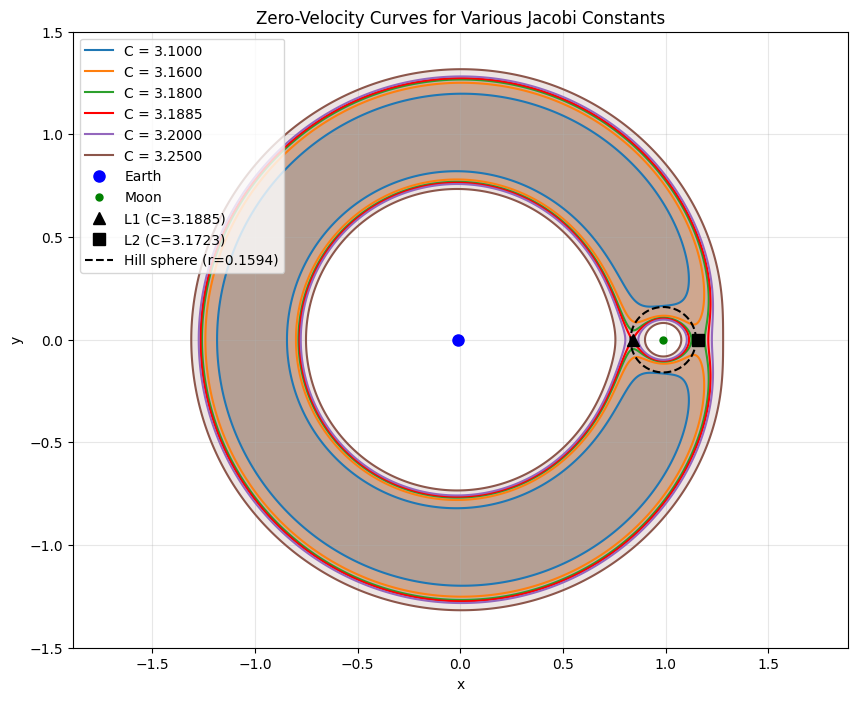

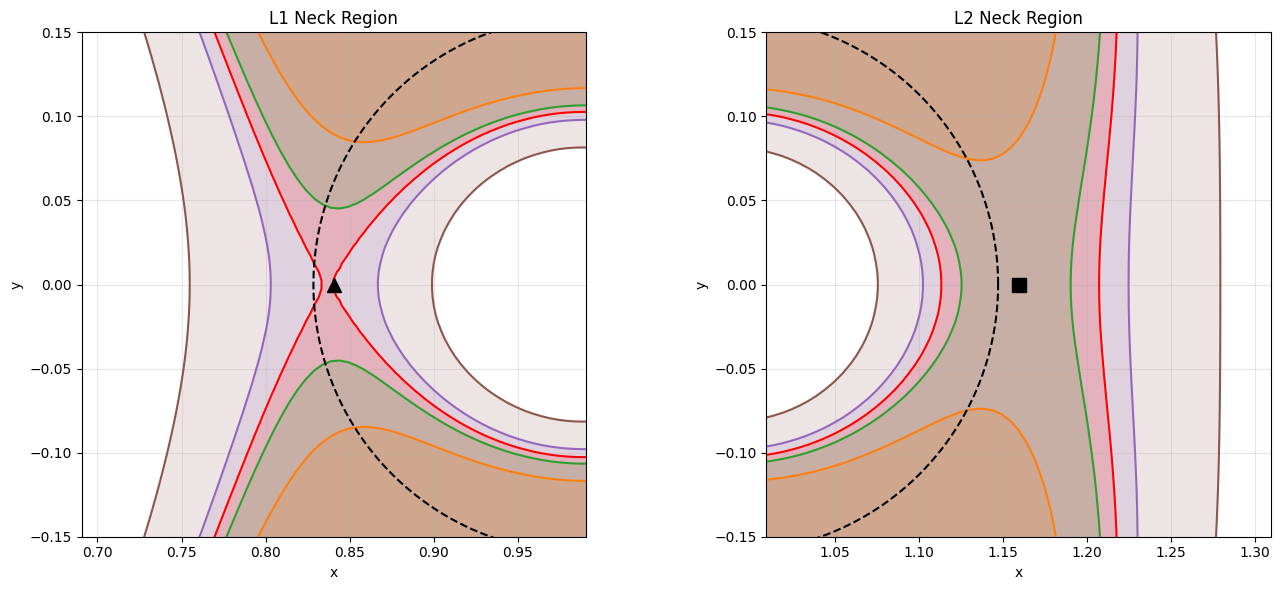

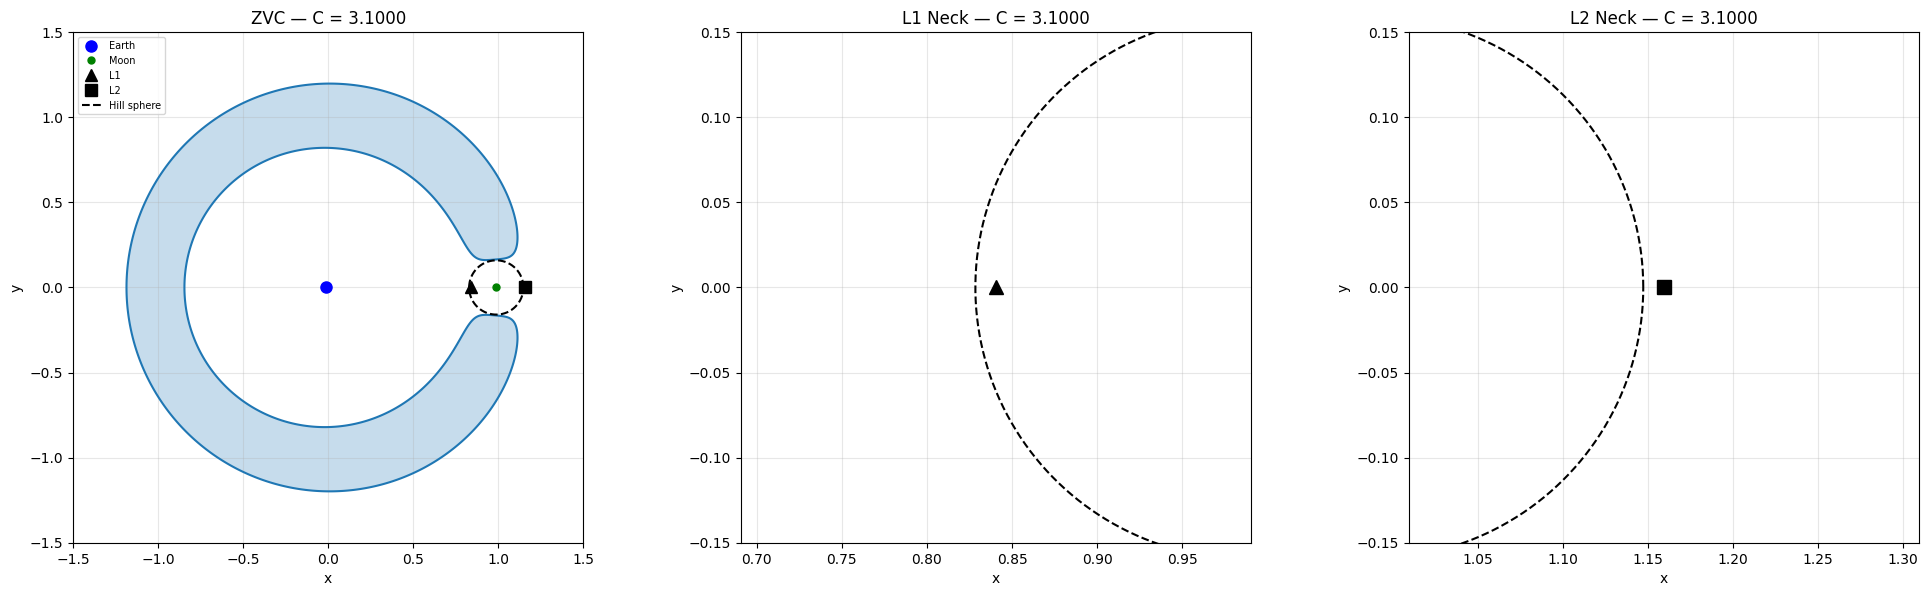

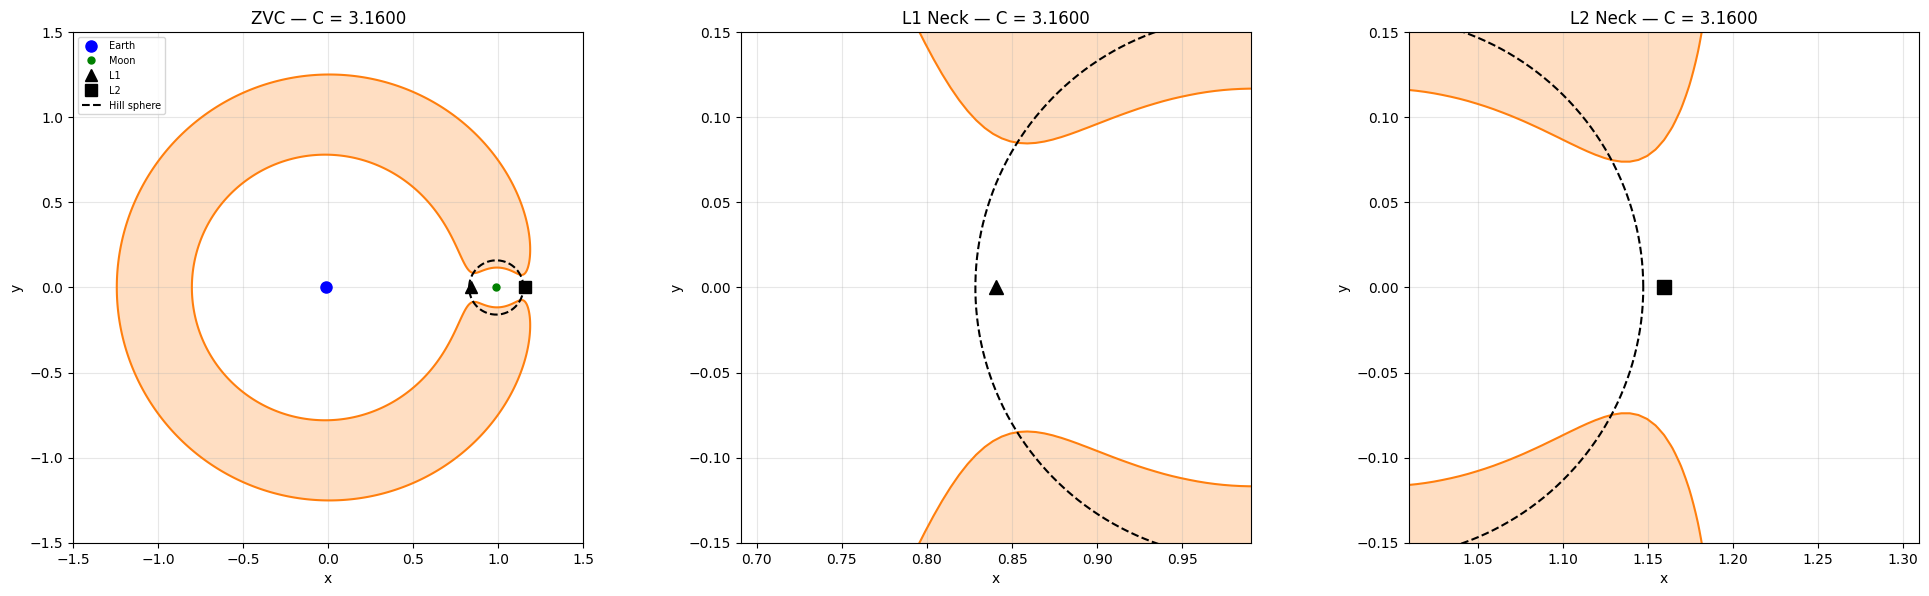

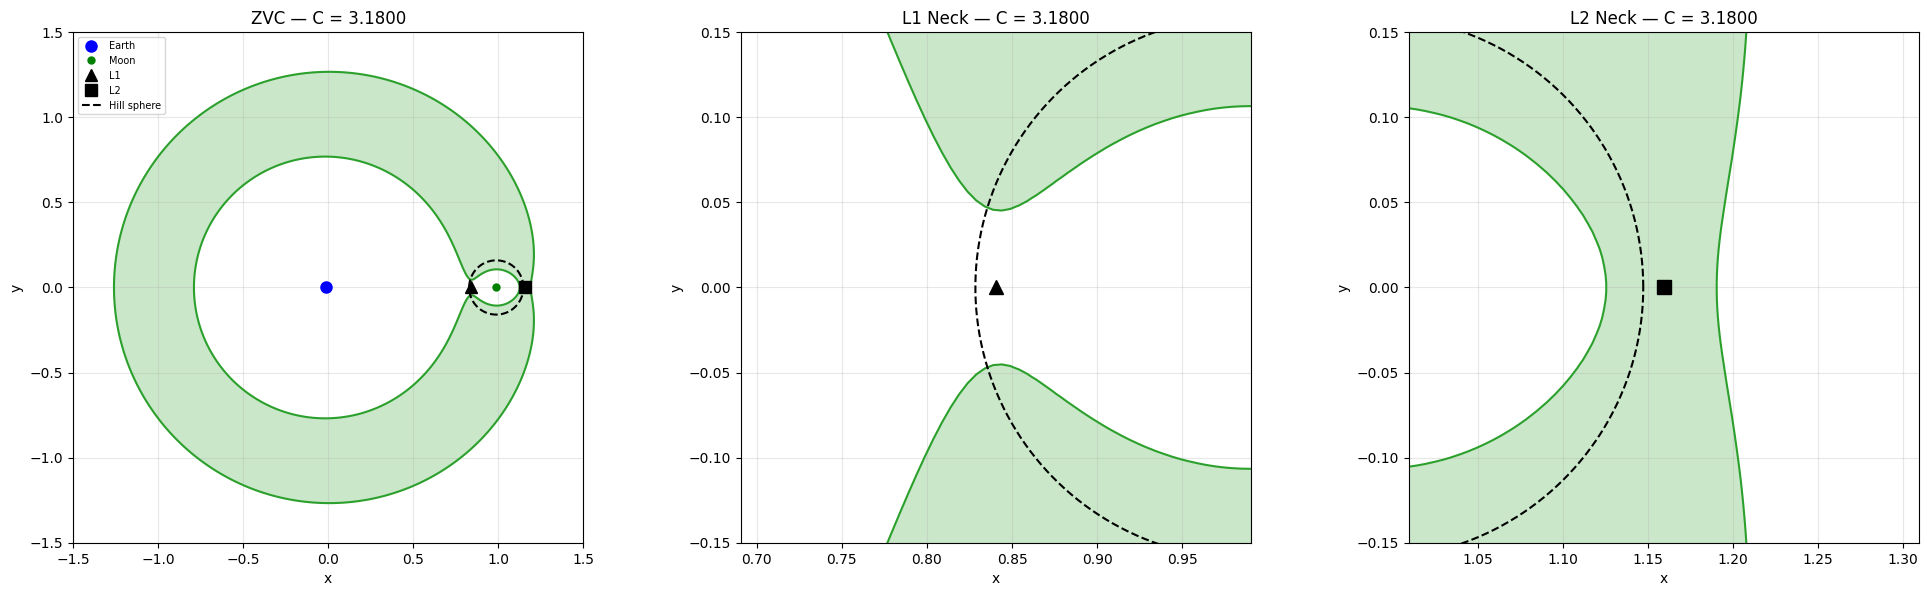

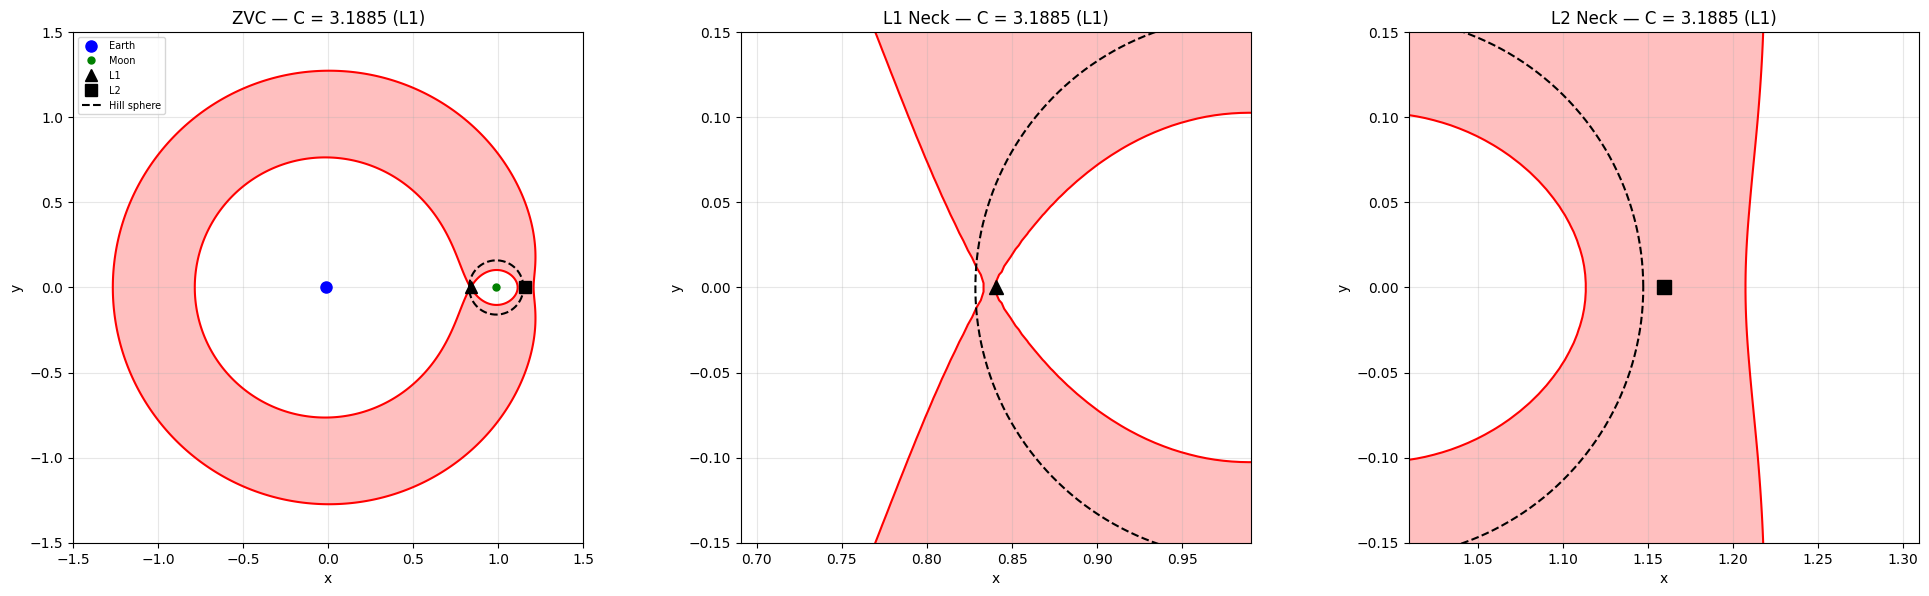

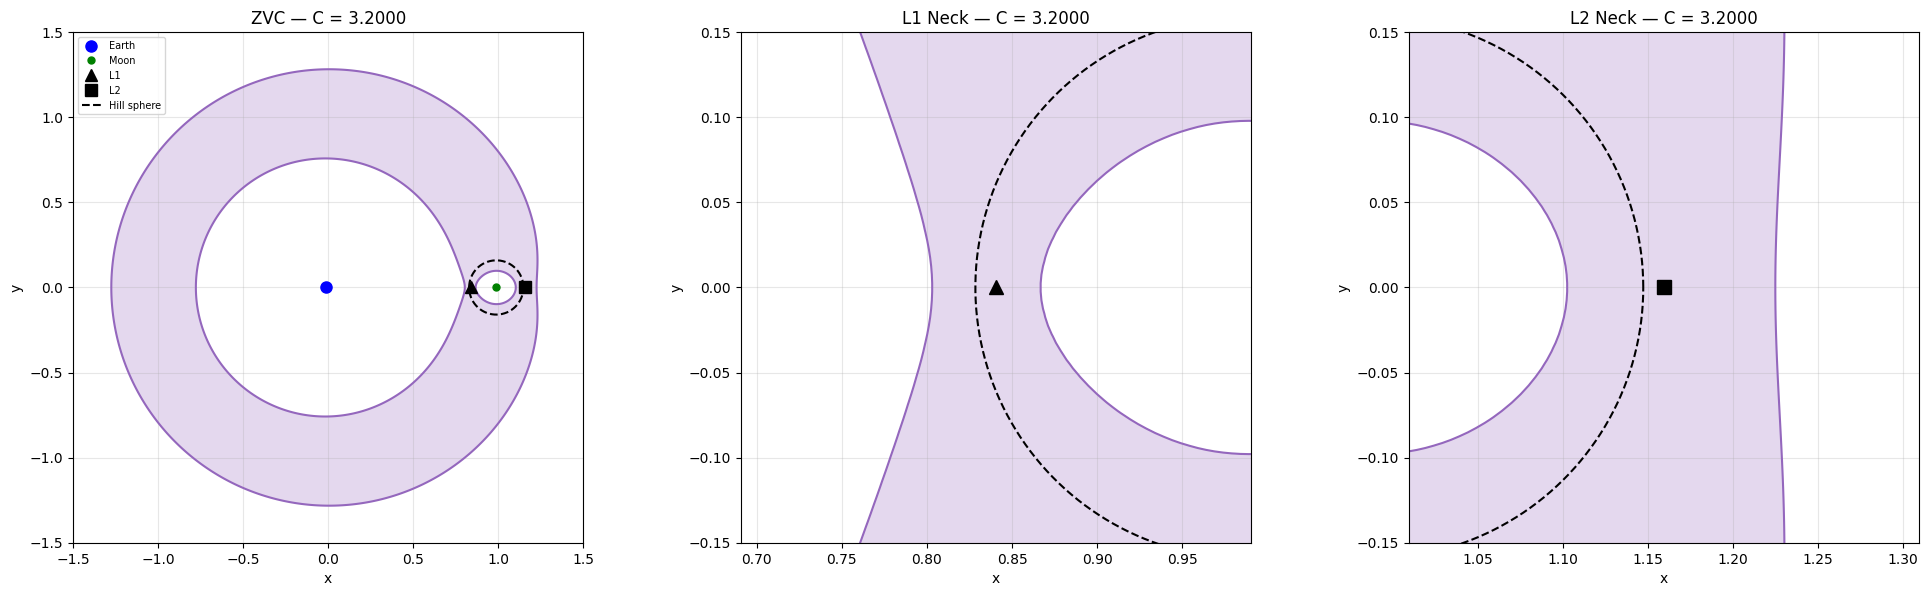

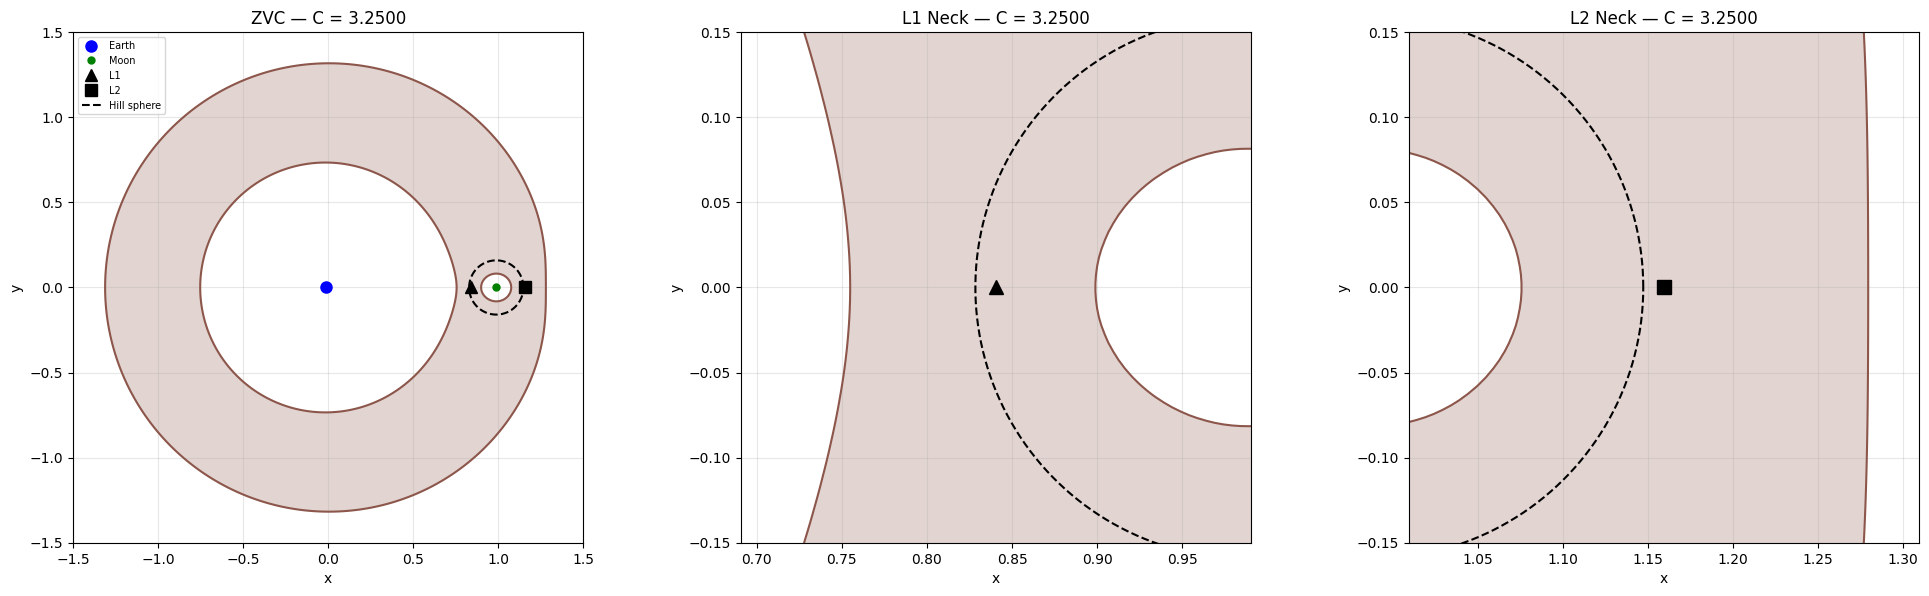

In [5]:
# plot zero velocity curves for various jacobi constants
L1 = np.array([L1_x, 0, 0])
L2 = np.array([L2_x, 0, 0])
jacobi_L1 = calc_Jacobi_constant(np.concatenate((L1, np.zeros(3))), mu)

# build 2D effective potential grid
xg = np.linspace(-1.5, 1.5, 600)
yg = np.linspace(-1.5, 1.5, 600)
Xg, Yg = np.meshgrid(xg, yg)
r1g = np.sqrt((Xg + mu)**2 + Yg**2)
r2g = np.sqrt((Xg - 1 + mu)**2 + Yg**2)
twoU = 2 * ((1 - mu) / r1g + mu / r2g + 0.5 * (Xg**2 + Yg**2))

jacobi_values = [3.10, 3.16, 3.18, jacobi_L1, 3.20, 3.25]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'red', 'tab:purple', 'tab:brown']

r_hill = (mu / 3)**(1/3)
theta = np.linspace(0, 2*np.pi, 200)
jacobi_L2 = calc_Jacobi_constant(np.concatenate((L2, np.zeros(3))), mu)
neck_pad = 0.15  # half-width of zoom window around each Lagrange point

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# --- main plot ---
ax0 = axes[0]
for C, color in zip(jacobi_values[::-1], colors[::-1]):
    ax0.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.15)
for C, color in zip(jacobi_values, colors):
    ax0.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    ax0.plot([], [], color=color, label=f'C = {C:.4f}')
ax0.plot(pos_earth[0], pos_earth[1], 'bo', ms=8, label='Earth')
ax0.plot(pos_moon[0], pos_moon[1], 'go', ms=5, label='Moon')
ax0.plot(L1[0], L1[1], 'k^', ms=8, label=f'L1 (C={jacobi_L1:.4f})')
ax0.plot(L2[0], L2[1], 'ks', ms=8, label=f'L2 (C={jacobi_L2:.4f})')
ax0.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
         'k--', linewidth=1.5, label=f'Hill sphere (r={r_hill:.4f})')
ax0.set_xlabel('x'); ax0.set_ylabel('y')
ax0.set_title('Zero-Velocity Curves')
ax0.legend(loc='upper left', fontsize=7)
ax0.set_aspect('equal')
ax0.grid(True, alpha=0.3)
ax0.set_xlim(-1.5, 1.5); ax0.set_ylim(-1.5, 1.5)
ax0.set_visible(False)
plt.close(fig)

# --- standalone main plot ---
plt.figure(figsize=(10, 8))
for C, color in zip(jacobi_values[::-1], colors[::-1]):
    plt.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.15)
for C, color in zip(jacobi_values, colors):
    plt.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    plt.plot([], [], color=color, label=f'C = {C:.4f}')
plt.plot(pos_earth[0], pos_earth[1], 'bo', ms=8, label='Earth')
plt.plot(pos_moon[0], pos_moon[1], 'go', ms=5, label='Moon')
plt.plot(L1[0], L1[1], 'k^', ms=8, label=f'L1 (C={jacobi_L1:.4f})')
plt.plot(L2[0], L2[1], 'ks', ms=8, label=f'L2 (C={jacobi_L2:.4f})')
plt.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
         'k--', linewidth=1.5, label=f'Hill sphere (r={r_hill:.4f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Zero-Velocity Curves for Various Jacobi Constants')
plt.legend(loc='upper left')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.xlim(-1.5, 1.5); plt.ylim(-1.5, 1.5)
plt.show()

# --- L1 / L2 neck zoom ---
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for C, color in zip(jacobi_values[::-1], colors[::-1]):
    ax1.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.15)
for C, color in zip(jacobi_values, colors):
    ax1.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
ax1.plot(L1[0], L1[1], 'k^', ms=10)
ax1.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
         'k--', linewidth=1.5)
ax1.set_xlim(L1_x - neck_pad, L1_x + neck_pad)
ax1.set_ylim(-neck_pad, neck_pad)
ax1.set_aspect('equal')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('L1 Neck Region')
ax1.grid(True, alpha=0.3)

# --- L2 neck zoom ---
for C, color in zip(jacobi_values[::-1], colors[::-1]):
    ax2.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.15)
for C, color in zip(jacobi_values, colors):
    ax2.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
ax2.plot(L2[0], L2[1], 'ks', ms=10)
ax2.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
         'k--', linewidth=1.5)
ax2.set_xlim(L2_x - neck_pad, L2_x + neck_pad)
ax2.set_ylim(-neck_pad, neck_pad)
ax2.set_aspect('equal')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('L2 Neck Region')
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()

# --- separate plot for each C value ---
for C, color in zip(jacobi_values, colors):
    label = f'C = {C:.4f}'
    if np.isclose(C, jacobi_L1):
        label += ' (L1)'

    fig_i, (ax_main, ax_l1, ax_l2) = plt.subplots(1, 3, figsize=(20, 6))

    # full view
    ax_main.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.25)
    ax_main.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    ax_main.plot(pos_earth[0], pos_earth[1], 'bo', ms=8, label='Earth')
    ax_main.plot(pos_moon[0], pos_moon[1], 'go', ms=5, label='Moon')
    ax_main.plot(L1[0], L1[1], 'k^', ms=8, label='L1')
    ax_main.plot(L2[0], L2[1], 'ks', ms=8, label='L2')
    ax_main.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
                 'k--', linewidth=1.5, label='Hill sphere')
    ax_main.set_xlabel('x'); ax_main.set_ylabel('y')
    ax_main.set_title(f'ZVC — {label}')
    ax_main.legend(loc='upper left', fontsize=7)
    ax_main.set_aspect('equal')
    ax_main.grid(True, alpha=0.3)
    ax_main.set_xlim(-1.5, 1.5); ax_main.set_ylim(-1.5, 1.5)

    # L1 zoom
    ax_l1.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.25)
    ax_l1.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    ax_l1.plot(L1[0], L1[1], 'k^', ms=10)
    ax_l1.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
               'k--', linewidth=1.5)
    ax_l1.set_xlim(L1_x - neck_pad, L1_x + neck_pad)
    ax_l1.set_ylim(-neck_pad, neck_pad)
    ax_l1.set_aspect('equal')
    ax_l1.set_xlabel('x'); ax_l1.set_ylabel('y')
    ax_l1.set_title(f'L1 Neck — {label}')
    ax_l1.grid(True, alpha=0.3)

    # L2 zoom
    ax_l2.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.25)
    ax_l2.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    ax_l2.plot(L2[0], L2[1], 'ks', ms=10)
    ax_l2.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
               'k--', linewidth=1.5)
    ax_l2.set_xlim(L2_x - neck_pad, L2_x + neck_pad)
    ax_l2.set_ylim(-neck_pad, neck_pad)
    ax_l2.set_aspect('equal')
    ax_l2.set_xlabel('x'); ax_l2.set_ylabel('y')
    ax_l2.set_title(f'L2 Neck — {label}')
    ax_l2.grid(True, alpha=0.3)

    fig_i.tight_layout()
    plt.show()




1.2 Define Capture Metrics (Critical)
Choose objective, computable criteria.
Minimum recommended:

Particle inside Moon's Hill sphere 
Moon‑relative Kepler energy < 0 
Residence time T>TminT > T_{min} (e.g., multiple moon revolutions) 

Deliverable

Formal capture definition 
Flowchart for trajectory classification: Fly‑by 
Temporary capture 
Impact 
Escape 



Phase 2 — Phase‑Space Geometry
Goal: Show you understand why capture occurs.
2.1 L1/L2 Structure

Compute collinear Lagrange points 
Plot ZVCs near neck opening 
Identify energy threshold for Earth access 
Deliverable

ZVC plots showing capture‑accessible regimes 
Explanation of neck dynamics 


Jacobi levelPhase‑space geometryC>CL1C > C_{L1}C>CL1​Moon region isolatedC=CL1C = C_{L1}C=CL1​Bottleneck (neck) opensC<CL1C < C_{L1}C<CL1​Transit between Earth ↔ Moon possible





 2.2 Periodic Orbits & Manifolds (Core Non‑Trivial Element)

Compute planar Lyapunov orbits about L1 and/or L2 
Linearize → monodromy matrix 
Generate stable and unstable manifolds 
Deliverable

Manifold tubes in configuration space 
Short explanation of transport mechanism 

This is where your project crosses from “numerical experiment” to celestial mechanics.




In [4]:
# Compute planar Lyapunov orbits about L1 and/or L2 and analyze their stability properties.




Phase 3 — Capture Experiments
Goal: Connect manifolds to actual captured trajectories.
3.1 Energy Sweep Experiment

Sample initial conditions on a Poincaré section 
Sweep Jacobi constant near L1/L2 opening 
Track capture probability 
Deliverables

Capture probability vs CC 
Phase‑space slices with capture regions highlighted 



3.2 Monte‑Carlo Injection

Inject particles near L1/L2 region 
Integrate forward in time 
Classify outcomes 
Deliverables

Outcome maps 
Residence‑time histograms 
Example long‑lived capture trajectories 



3.3 Manifold Overlay (Key Insight)

Overlay captured trajectories on invariant manifolds 
Demonstrate that long‑lived captures shadow stable manifolds 
Deliverable

Single figure showing manifolds + capture trajectories 
This figure often becomes the centerpiece of the project 



Phase 4 — Sensitivity & Chaos
Goal: Show understanding of instability and transient nature.

Perturb initial conditions slightly 
Measure variation in capture time 
Identify chaotic sensitivity near separatrices 
Deliverables

ΔIC vs Δcapture‑time plot 
Short discussion of chaotic transport 



Phase 6 — Synthesis & Interpretation
Goal: Demonstrate understanding, not just results.
You should be able to answer:

Why capture is rare 
Why it is temporary 
Why manifolds matter 
Why duration varies wildly 
Deliverables

Final discussion section 
Physical interpretation in plain language 



Final Report Structure (Suggested)

Introduction & Motivation 
Dynamical Model 
Capture Definition 
Phase‑Space Geometry 
Numerical Experiments 
Results 
Physical Interpretation 
Limitations & Extensions 
